## Import Library

In [1]:
# Import Library
import pandas as pd
import re
import emoji
import numpy as np

# Import library untuk EDA
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

# Import Library Data Splitting & Tokenization
from sklearn.model_selection import train_test_split
import torch
from transformers import AutoTokenizer

## Load Data

In [3]:
# Membaca Dataset
dataset1 = pd.read_csv('tokopedia-product-reviews-2019.csv')
dataset2 = pd.read_csv('tokopedia_product_reviews_2025.csv')
dataset3 = pd.read_csv('reviews_output.csv')

# Menampilkan Info
display(dataset1.info())
display(dataset2.info())
display(dataset3.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40607 entries, 0 to 40606
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    40607 non-null  int64 
 1   text          40607 non-null  object
 2   rating        40607 non-null  int64 
 3   category      40607 non-null  object
 4   product_name  40607 non-null  object
 5   product_id    40607 non-null  int64 
 6   sold          40593 non-null  object
 7   shop_id       40607 non-null  int64 
 8   product_url   40607 non-null  object
dtypes: int64(4), object(5)
memory usage: 2.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65543 entries, 0 to 65542
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   review_text       65543 non-null  object
 1   review_date       65543 non-null  object
 2   review_id         65543 non-null  int64 
 3   product_name      65543 non-null  ob

In [4]:
# Menampilkan Dataset
display(dataset1.head())
display(dataset2.head())
display(dataset3.head())

,Unnamed: 0,text,rating,category,product_name,product_id,sold,shop_id,product_url
0,1,Barang sesuai pesanan dan cepat sampai,5,pertukangan,Staples Dekorasi Staples Kayu + Refill 8mm - Staples Gun 4-8 mm C Mart,418660637,1,1740837,https://www.tokopedia.com/shakaonline87/staples-dekorasi-staples-kayu-refill-8mm-staples-gun-4-8-mm-c-mart
1,2,Barang bagus harga murah,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMBAK HEKTER 022708,416032545,11,1477109,https://www.tokopedia.com/juraganperkakas/staple-gun-ats-3-way-tacker-staples-jok-tembak-hekter-022708
2,3,Paket rapi...mantap....cepat....sampe ke tujuan,5,pertukangan,STAPLE GUN ATS 3 WAY TACKER - STAPLES JOK TEMBAK HEKTER 022708,416032545,11,1477109,https://www.tokopedia.com/juraganperkakas/staple-gun-ats-3-way-tacker-staples-jok-tembak-hekter-022708
3,4,ya saya puas dgn barangnya,5,pertukangan,ALAT STAPLES TEMBAK &#40;AIR NAILER GUN&#41; OSSEL 1022J,102279869,5,771395,https://www.tokopedia.com/kamarmesin/alat-staples-tembak-air-nailer-gun-ossel-1022j
4,5,Responya luar biasa b mantap,5,pertukangan,Isi Refill Staples Jok Kulit Motor / Staple Gun Max t3-10 mb MAX,190679689,787,969999,https://www.tokopedia.com/mitrapersada/isi-refill-staples-jok-kulit-motor-staple-gun-max-t3-10-mb-max


,review_text,review_date,review_id,product_name,product_category,product_variant,product_price,product_url,product_id,rating,sold_count,shop_id,sentiment_label
0,"baru sekali ini terima brg dr belanja online dg packing super rapih dan aman. semula ragu, bagaimana mungkin mmbeli terlur ayam mentah , sec online. tp ternyata packing liar biasa. rapi, aman. Kerem seller",2024-12-22,1134256160,Telur Ayam Kampung Asli - Telur Mengandung Omega 3,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telur-ayam-kampung-asli-telur-mengandung-omega-3-1731491654043338692?extParam=ivf%3Dfalse,4601033481,5,1000000,8672687,positive
1,cocok bgt aku sama telur nya. nga Amis menurutku dan nga neg jadi nya. diterima dengan baik dan aman. terimakasih,2025-02-25,1242584634,Telur Ayam Kampung Asli - Telur Mengandung Omega 3,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telur-ayam-kampung-asli-telur-mengandung-omega-3-1731491654043338692?extParam=ivf%3Dfalse,4601033481,5,1000000,8672687,positive
2,"Telornya sudah sampai di rumah dengan kemasan yang sangat rapi, luar biasa. Terimakasih buat sellernya. Mantaps.",2025-07-15,1573444677,Telur Ayam Kampung Asli - Telur Mengandung Omega 3,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telur-ayam-kampung-asli-telur-mengandung-omega-3-1731491654043338692?extParam=ivf%3Dfalse,4601033481,5,1000000,8672687,positive
3,"Telor sudah diterima dengan baik dan tidak ada yang pecah, terimakasih buat sellernya.",2025-07-20,1581728541,Telur Ayam Kampung Asli - Telur Mengandung Omega 3,Makanan & Minuman,Box Polos,87000,https://www.tokopedia.com/indofarmproduct/telur-ayam-kampung-asli-telur-mengandung-omega-3-1731491654043338692?extParam=ivf%3Dfalse,4601033481,5,1000000,8672687,positive
4,"Alhamdulillah penjual amanah,Telor nya terbaik,sedap lezat sekali di bikin telor setengah matang.pembelian ke 2...In Syaa Allah menjadi langganan",2023-04-24,881041355,Telur Ayam Kampung Asli - Telur Mengandung Omega 3,Makanan & Minuman,Box Full Design,87000,https://www.tokopedia.com/indofarmproduct/telur-ayam-kampung-asli-telur-mengandung-omega-3-1731491654043338692?extParam=ivf%3Dfalse,4601033481,5,1000000,8672687,positive


,product_name,rating,message
0,[COD] Headset Bluetooth Nirkabel TWS CID17 dengan Mikrofon dan Pengisian Casing Elektronik Audio Headset Wireless Earphone - PINK,3.0,"Kejernihan lensa: Lumayan jernih\nKualitas pengerjaan: Rapi\nTapi sayang beli dua,yg satu tidak berfungsi normal,di cas gk bisa nambah,headset nya kadang konek kadang enggak,"
1,[COD] Headset Bluetooth Nirkabel TWS CID17 dengan Mikrofon dan Pengisian Casing Elektronik Audio Headset Wireless Earphone - PINK,3.0,"saya beli 3, dan 1 tidak berfungsi dengan baik (tws sebelah nya tidak ada suara) kedepannya coba untuk di cek terlebih dahulu sebelum lakukan pengiriman trima kasih"
2,[COD] Headset Bluetooth Nirkabel TWS CID17 dengan Mikrofon dan Pengisian Casing Elektronik Audio Headset Wireless Earphone - PINK,3.0,"Ka ko punyaku kaya gini, terus ganyala si yg kotaknya itu"
3,[COD] Headset Bluetooth Nirkabel TWS CID17 dengan Mikrofon dan Pengisian Casing Elektronik Audio Headset Wireless Earphone - PINK,2.0,"Alhamdulillah paketnya sudah datang dengan selamat dan amanah,terimakasih dan isi nya sesuai dengan warna yg di request Kualitasnya bagus kurirnya juga ramah... \nSuka pokoknya ga ngecewain \nAku milih warna biru😻🫶\nKualitas pengerjaan: Bagus"
4,[COD] Headset Bluetooth Nirkabel TWS CID17 dengan Mikrofon dan Pengisian Casing Elektronik Audio Headset Wireless Earphone - PINK,1.0,"Batre Kosong, Barang sesuai Tidak Normal suara pecah dan pecah dan yang 1 gak aktif (mati)."


In [5]:
# Mengambil Kolom Ulasan dan Rating
dataset1 = dataset1[['text', 'rating']]
dataset2 = dataset2[['review_text', 'rating']]
dataset3 = dataset3[['message', 'rating']]

# Mengubah Nama Kolom
dataset1.columns = ['ulasan', 'rating']
dataset2.columns = ['ulasan', 'rating']
dataset3.columns = ['ulasan', 'rating']

# Menggabungkan Dataset
dataset = pd.concat([dataset1, dataset2, dataset3], ignore_index=True)


## Preprocessing

In [7]:
# Menampilkan Dataset
display(dataset.head())

# Menampilkan Info
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ulasan  12000 non-null  object 
 1   rating  12000 non-null  float64
dtypes: float64(1), object(1)
memory usage: 187.6+ KB


,ulasan,rating
0,Engga sesuai pesanan penipuan\nOrng pesan banyak malah dapat dua bucis aja,1.0
1,Recomended enak di pakai dah 2x beli,5.0
2,"Suara gak perlu diragukan.detail,jernih khas Sony.barang ori.BNiB.trusted seller.reccomend",5.0
3,murah banget lg da VC diskon,5.0
4,"respon dan pengiriman cepat, cartridge sudah dipasang dan ok",5.0


In [8]:
# Melihat Informasi Statistik Ulasan
display(pd.DataFrame(dataset['ulasan'].str.len().describe().round(0)))
dataset.describe().round(0)

,ulasan
count,12000.0
mean,67.0
std,128.0
min,1.0
25%,29.0
50%,47.0
75%,78.0
max,6772.0


In [9]:
# Mengecek Isi Dataset
print(f'Jumlah Duplikat : {dataset.duplicated().sum()}')
print(f'Jumlah Null     : \n{dataset.isna().sum()}')
print(f"Jumlah Data Kosong : {(dataset['ulasan'].str.strip() == ' ').sum()}")

# Menghapus Data Duplikat
dataset = dataset.drop_duplicates()
print(f'Jumlah Duplikat : {dataset.duplicated().sum()}')
print(f'Jumlah Dataset  : {len(dataset)}')

Jumlah Duplikat : 370
Jumlah Null     : 
ulasan    0
rating    0
dtype: int64
Jumlah Data Kosong : 0
Jumlah Duplikat : 0
Jumlah Dataset  : 11630


In [10]:
# Menampilkan Isi Yang Jumlah Karakternya Max
display(
    pd.DataFrame({
        'ulasan': dataset['ulasan'],
        'panjang_karakter': dataset['ulasan'].str.len()
    })
    .sort_values('panjang_karakter', ascending=False)
    .head(20)
)

ulasan  panjang_karakter
4677   Bismillahirohmanirohim assalamualaikum warrohm...              6772
6522   &gt;&gt;&gt; Beli 3 pcs (6 kotak) yang datang ...              2355
7008   Saya membeli Powerbank (pb) ini untuk dikirim ...              1759
11134  Produk bagus, well recommended. Model barang s...              1369
7344   Awalnya PB yg saya beli membutuhkan waktu char...              1177
3769   Yuk #GantiKeNasiYangLebihBaik Buat teman teman...              1081
5868   Reveiw Negatif: \n1. Barang sampai masih terse...              1076
2311   Emang boleh se ajaib ini? Dulu anakku gtm para...              1048
6896   Tolak Angin adalah obat herbal yang bermanfaat...              1021
1278   Alhamdulillah Powerbank datang dengan Selamat,...               957
3397   Pelayanan sejak mulai tanya-tanya hingga trans...               849
7515   Saya pesan 3 barang, 2 tidak ada masalah, tapi...               765
3232   beli yd banyak ... ud lama juga langanan pas b...               751
1258   Dari awal launching HA, pengen bgt cobain bond...               715
7721   thankyou so much buat yg kreasiin broth ini da...               669
6794   Los pueblos originales malayo-polinesios nunca...               628
3233   Minya enak banget,, tebel kenyal kenyal, porsi...               619
5928   Komunikasi / chat dengan Penjual kurang tangga...               613
104    Barang Original, Pengiriman Super Rapih Dibung...               611
7380   Yang mau beli ini sebaiknya fikir-fikir 7x.\nP...               596

In [11]:
# Melihat Ulasan Yang Hanya Berisi Simbol
simbol = dataset['ulasan'].apply(lambda x: len(str(x).strip('.!?,-_*/;& ')) == 0)

print("Jumlah simbol saja:", simbol.sum())

df_simbol = dataset[simbol][['ulasan']]
df_simbol

Jumlah simbol saja: 31


In [12]:
# Fungsi Preprocessing Teks (Punctuation-preserving & spacing for BERT)
def preprocessing_teks(teks):
    # Formatting Teks
    teks = str(teks).lower()

    # Hapus URL
    teks = re.sub(r'https?://\S+|www\.\S+', '', teks)
    teks = re.sub(r'\b\S+\.(com|co\.id|id|net|org|io|app|xyz)(\S*)', '', teks)

    # Menghapus Hastag dan Mention
    teks = re.sub(r'[@#]\S+', '', teks)

    # Menghapus Karakter Berulang
    teks = re.sub(r'(.)\1{2,}', r'\1', teks)

    # Merubah Icon Emoji Menjadi Teks
    teks = emoji.demojize(teks, delimiters=(" ", " "))
    teks = teks.replace("_", " ")

    # Mengubah semua tanda baca selain huruf/angka/spasi/.,!? menjadi spasi
    teks = re.sub(r'[^a-zA-Z0-9\s.,!?]', ' ', teks)

    # Memberikan spasi di sekitar tanda baca agar slang mapping bekerja dengan baik
    teks = re.sub(r'([.,!?])', r' \1 ', teks)

    # Menghapus Spasi Berlebih
    teks = re.sub(r'\s+', ' ', teks).strip()

    # Mengatasi Ulasan Yang Cuman Simbol
    if len(teks) == 0:
        return ""

    return teks


In [13]:
# Membaca Dataset Kata Slang
data_slang = pd.read_csv('slang.csv')
data_slang = data_slang[['slang', 'formal']]

# Ubah Menjadi Dictionary
dict_slang = dict(
    zip(data_slang['slang'], data_slang['formal'])
)

# Fungsi Normalisasi Kata
def normalisasi_kata(teks):
    kata = teks.split()

    normalisasi = [
        dict_slang.get(word, word)
        for word in kata
    ]

    return " ".join(normalisasi)

In [14]:
# Menerapkan Fungsi Ke Dataset
dataset['ulasan'] = (
    dataset['ulasan']
    .apply(preprocessing_teks)
    .apply(normalisasi_kata)
)

## Cek Hasil Preprocessing

In [16]:
# Fungsi Validasi Hasil Processing
def cek_hasil_preprocessing(dataset, kolom='ulasan'):

    print("=" * 30)
    print("HASIL VALIDASI PREPROCESSING")
    print("=" * 30)

    hasil = {
        "URL":
            dataset[kolom].str.contains(
                r'https?://|www\.',
                regex=True,
                na=False
            ).sum(),

        "Mention/Hashtag":
            dataset[kolom].str.contains(
                r'@\w+|#\w+',
                regex=True,
                na=False
            ).sum(),

        "Emoji":
            dataset[kolom].apply(
                lambda x: len(emoji.emoji_list(str(x))) > 0
            ).sum(),

        "Karakter Berulang":
            dataset[kolom].apply(
                lambda x: bool(re.search(r'(.)\1{2,}', str(x)))
            ).sum(),

        "Karakter Aneh":
            dataset[kolom].str.contains(
                r'[^\w\s.,?!*/&-]',
                regex=True,
                na=False
            ).sum(),

        "Spasi Berlebih":
            dataset[kolom].str.contains(
                r'\s{2,}',
                regex=True,
                na=False
            ).sum(),

        "Review Kosong":
            (
                dataset[kolom]
                .fillna('')
                .str.strip() == ''
            ).sum()
    }

    for item, jumlah in hasil.items():
        print(f"{item:<20} : {jumlah}")

    print(f'\nJumlah Dataset       : {len(dataset)}')

In [17]:
cek_hasil_preprocessing(dataset)

HASIL VALIDASI PREPROCESSING
URL                  : 0
Mention/Hashtag      : 0
Emoji                : 0
Karakter Berulang    : 0
Karakter Aneh        : 0
Spasi Berlebih       : 0
Review Kosong        : 9

Jumlah Dataset       : 11630


In [18]:
# Menghapus Kata Yang Panjang dan Berulang
dataset = dataset[dataset['ulasan'].str.len() < 1400]

display(
    pd.DataFrame({
        'ulasan': dataset['ulasan'],
        'panjang_karakter': dataset['ulasan'].str.len()
    })
    .sort_values('panjang_karakter', ascending=False)
    .head(10)
)

,ulasan,panjang_karakter
11134,"produk bagus , well recommended . model barang sama persis dengan yang dijual di a e hardware tapi harga jauh lebih murah di sini entah karena lagi promo atau harga aslinya memang under 300k , ukuran juga sesuai dan yang paling penting barang sesuai dengan foto etalase . saya beli memang tujuan utama untuk dipakai anabul dan kebetulan ukuran pas banget , anabulnya juga betah di dalam troli . hal yang perlu diperhatikan dan mungkin bisa dijadikan catatan sebagai pengembangan pelayanan dari toko juga pesan untuk calon pembeli toko tidak menyertakan bubble wrap pada orderan ini dan harus menambah biaya bayar 10ribu rupiah jika ingin di bubble wrap , seharusnya sih sebagai toko official seperti ini , bubble wrap sudah wajib termasuk dalam harga barang , mengingat harga barang cukup mahal dan bubble wrap barang ukuran seperti ini tidak mungkin habis 10rb rupiah , bisa saja menambahkan opsi extra bubble wrap jika ada yang ingin memesan , bukannya memang sama sekali tidak di wrapping dengan bubble wrap jika tidak menambah bayar 10rb rupiah . jujur saja karena lokasi pengiriman saya cukup dekat dengan toko , saya tidak membayar untuk bubble wrap dan paket hanya dibungkus dengan karung . syukurnya paket datang dengan keadaan aman dan tidak ada bagian yang pecah . jadi di sini saya tidak komplain , melainkan hanya pesan saja kepada toko dan calon pembeli selanjutnya .",1380
3769,"yuk buat teman teman yang ingin mencari pengganti nasi putih yang rasanya lebih nikmat dan gizinya juga lebih baik , aku rekomendasikan untuk ganti ke daily meal rice by topi koki group varian nasi jagung atau nasi singkong . kenapa harus daily meal rice ? check box with check bebas gula check box with check bebas gluten check box with check tinggi serat check box with check 100 dari singkong dan jagung pilihan berkualitas check box with check bpom amp halal terverifikasi check box with check lebih cepat masak dari nasi putih biasa jadi lebih menghemat waktu selain itu daily meal rice varian nasi jagung dan nasi singkong juga bermanfaat check box with check membantu menstabilkan gula darah check box with check untuk melancarkan percernaan check box with check untuk mengatasi asam lambung check box with check untuk mengurangi resiko terkena kanker usus check box with check membantu mengotrol kolestrol check box with check menjaga kesehatan jantung check box with check dan masih banyak lagi manfaat dari daily meal rice varian nasi jagung dan nasi singkong yuk buat teman teman yang mau mencoba kini tersedia di salah satu commerce di tokopedia dan topi koki official store . ayo mulai menjalankan pola makan sehat dari sekarang red heart",1251
7344,"awalnya pb yang saya beli membutuhkan waktu charge lebih dari 6 jam untuk penuh . bahkan hingga 6 jam belum penuh juga . kabel bawaan dari pb tidak support untuk fast charging . akhirnya saya menggunakan kabel bawaan hp . kapasitas pb tidak real 10 . 0 mah . charge hp dengan battery 50 mah hanya bisa charge 1x full dan 1x hanya sampai 40 . penjual sangat koperatif . bersedia menjelaskan detil pb dan mau recheck kondisi pbnya . ini contoh penjelasan dari penjual menghitung berapa kali sebuah power bank bisa melakukan charging hp tidak semudah perhitungan pembagian matematika dasar ya . ada proses fisika yang terjadi disini . power bank itu terdiri dari baterai , mother board , dan usb untuk output . tegangan baterai itu 3 , 7 volt . sedangkan tegangan usb itu 5 volt . ada perbedaan tegangan antara baterai dan usb 3 , 7 volt 5 volt 0 . 74 ini adalah koefisien yang digunakan untuk menghitung daya yang dapat digunakan dari sebuah power bank . 10mah kali 0 . 74 7400mah jadi artinya sebuah power bank yang real 10 . 0mah hanya bisa mengeluarkan daya 7 . 400mah yang bisa digunakan untuk mengisi smarphone kamu . semoga ulasan saya bisa dipelajari oleh para calon pembeli",1179
2311,"memang boleh se ajaib ini ? dulu anakku gtm parah sampai umur 1th sampai bb nya kurang , habis itu pertama kalinya coba

In [19]:
# Mengecek Isi Dataset
print(f'Jumlah Duplikat : {dataset.duplicated().sum()}')
print(f'Jumlah Null     : \n{dataset.isna().sum()}')
print(f"Jumlah Data Kosong : {(dataset['ulasan'].str.strip() == ' ').sum()}")

# Menghapus Data Duplikat
dataset = dataset.drop_duplicates()
print(f'Jumlah Duplikat : {dataset.duplicated().sum()}')
print(f'Jumlah Dataset  : {len(dataset)}')

Jumlah Duplikat : 572
Jumlah Null     : 
ulasan    0
rating    0
dtype: int64
Jumlah Data Kosong : 0
Jumlah Duplikat : 0
Jumlah Dataset  : 11055


In [20]:
cek_hasil_preprocessing(dataset)

HASIL VALIDASI PREPROCESSING
URL                  : 0
Mention/Hashtag      : 0
Emoji                : 0
Karakter Berulang    : 0
Karakter Aneh        : 0
Spasi Berlebih       : 0
Review Kosong        : 3

Jumlah Dataset       : 11055


In [21]:
# Melihat Informasi Statistik Ulasan
display(pd.DataFrame(dataset['ulasan'].str.len().describe().round(0)))
dataset.describe().round(0)

,ulasan
count,11055.0
mean,73.0
std,74.0
min,0.0
25%,31.0
50%,53.0
75%,90.0
max,1380.0


In [22]:
# Menampilkan Dataset
dataset.head(10)

## Labeling

In [24]:
# Load Kamus
lexicon_positive = pd.read_csv(
    'lexicon_positive.tsv',
    sep='\t',
    header=0
)

lexicon_positive.columns = [
    'word',
    'weight'
]

lexicon_positive.head(10)

In [25]:
lexicon_negative = pd.read_csv(
    'lexicon_negative.tsv',
    sep='\t',
    header=0
)

lexicon_negative.columns = [
    'word',
    'weight'
]

lexicon_negative.head(10)

In [26]:
# Membuat Dictionary Positif
positive_dict = {}
for index, row in lexicon_positive.iterrows():
    positive_dict[row['word']] = int(row['weight'])

In [27]:
# Membuat Dictionary Negatif
negative_dict = {}
for index, row in lexicon_negative.iterrows():
    negative_dict[row['word']] = int(row['weight'])

In [28]:
# Membuat Fungsi Scoring
def sentiment_score(text):

    words = text.split()

    score = 0

    for word in words:

        if word in positive_dict:
            score += positive_dict[word]

        elif word in negative_dict:
            score += negative_dict[word]

    return score

In [29]:
dataset.columns

In [30]:
# 1. Menambahkan istilah khusus  ke kamus positif
kata_ecommerce_positif = {
    'aman': 4,
    'packing': 3,
    'deskripsi': 2,
    'fast': 3,
    'thumbs': 3,
    'ori': 4,
    'original': 4,
    'berfungsi': 3,
    'normal': 2,
    'lancar': 3
}

# Update dictionary positif
positive_dict.update(kata_ecommerce_positif)


# 2. Daftar kata yang salah masuk di kamus negatif
kata_salah_negatif = [
    'cepat', 'bagus', 'sudah', 'pengiriman', 'yang',
    'kasih', 'sampai', 'baik', 'rapi', 'deskripsi',
    'sangat', 'saya', 'ada', 'enak'
]

# Hapus kata-kata tersebut dari kamus negatif
for kata in kata_salah_negatif:
    if kata in negative_dict:
        del negative_dict[kata]

print("Kamus berhasil di-update dan dibersihkan!")

Kamus berhasil di-update dan dibersihkan!


In [31]:
# Load kamus slang
df_slang = pd.read_csv('slang.csv') 

slang_dict = dict(zip(df_slang['slang'], df_slang['formal']))

def normalisasi_slang(text):
    if not isinstance(text, str):
        return ""
    words = text.split()
    normalized_words = [slang_dict.get(word, word) for word in words]
    return " ".join(normalized_words)

print("Kamus slang berhasil di-load!")

Kamus slang berhasil di-load!


In [32]:
# 1. Jalankan preprocessing teks asli
dataset['clean_text'] = dataset['ulasan'].apply(preprocessing_teks)

# 2. Lanjutkan dengan normalisasi slang
dataset['clean_text'] = dataset['clean_text'].apply(normalisasi_slang)

dataset[['ulasan','clean_text']].head()

In [33]:
# Daftar kata negasi
kata_negasi = ['tidak', 'bukan', 'kurang', 'tak', 'jangan', 'enggak', 'ga', 'gak', 'ngga', 'nggak', 'tdk', 'belom', 'belum']

def sentiment_score(text):
    if not isinstance(text, str):
        return 0
        
    words = text.split()
    score = 0
    
    for i, word in enumerate(words):
        bobot = 0
        
        # Cek bobot di kamus positif/negatif
        if word in positive_dict:
            bobot = positive_dict[word]
        elif word in negative_dict:
            bobot = negative_dict[word]
            
        # Jika kata ada di kamus (bobot tidak 0), terapkan logika negasi
        if bobot != 0:
            if i > 0 and words[i-1] in kata_negasi:
                bobot = bobot * -1 # Balikkan nilainya
            score += bobot
            
    return score

# Eksekusi scoring
dataset['score_sentimen'] = dataset['clean_text'].apply(sentiment_score)
dataset[['clean_text', 'score_sentimen']].head(10)

In [34]:
# Filter margin kontradiksi (label noise cleaning dengan lexicon)
# Hapus review positif (rating 4-5) dengan skor sentimen <= -2 (negatif kuat)
# Hapus review negatif (rating 1-2) dengan skor sentimen >= 2 (positif kuat)
cond_pos_contradiction = (dataset['rating'] >= 4) & (dataset['score_sentimen'] <= -2)
cond_neg_contradiction = (dataset['rating'] <= 2) & (dataset['score_sentimen'] >= 2)
dataset = dataset[~(cond_pos_contradiction | cond_neg_contradiction)]
print('Filter margin kontradiksi berhasil diterapkan!')


Filter margin kontradiksi berhasil diterapkan!


In [35]:
# Terapkan fungsi labeling berbasis rating dengan menyertakan seluruh baris
def rating_label(row):
    rating = row['rating']
    if rating <= 2.0:
        return 'Negatif'
    elif rating >= 4.0:
        return 'Positif'
    else:
        return 'Netral'

dataset['label'] = dataset.apply(rating_label, axis=1)


In [36]:
# Cek hasil akhirnya
display(dataset[['rating', 'clean_text', 'score_sentimen', 'label']].head(10))

,rating,clean_text,score_sentimen,label
0,1.0,enggak sesuai pesanan penipuan orang pesan banyak malah dapat dua bucis saja,2,Positif
1,5.0,recomended enak di pakai deh 2x beli,7,Positif
2,5.0,"suara enggak perlu diragukan . detail , jernih khas sony . barang orisinal . bnib . trusted seller . reccomend",13,Positif
3,5.0,murah banget lagi deh vc diskon,3,Positif
4,5.0,"respon dan pengiriman cepat , cartridge sudah dipasang dan ok",12,Positif
5,4.0,bagus . sesuai deskripsi,7,Positif
6,5.0,pelayanan yang ramah dan memuaskan dari mayapada clinic sudirman . angkat jempol untuk staff dan dokter disana .,17,Positif
7,5.0,paket sudah diterima dengan baik dan aman terima kasih banyak . .,23,Positif
8,5.0,"dapat hadiah ini dari pembelian varian berry burst . sudah lama konsumsi quaker , enak rasanya tidak terlalu manis . cukup isi perut di pagi hari . thumbs up",15,Positif
9,5.0,"packing rapi , pengiriman cepat , kurir baik",12,Positif


## Exploratory Data Analysis

In [38]:
# Balancing classes (menggunakan 12000 sample per kelas)
df_pos = dataset[dataset['label'] == 'Positif']
df_neg = dataset[dataset['label'] == 'Negatif']
df_net = dataset[dataset['label'] == 'Netral']

target_samples = 12000
df_pos_under = resample(df_pos, replace=len(df_pos) < target_samples, n_samples=target_samples, random_state=42)
df_neg_under = resample(df_neg, replace=len(df_neg) < target_samples, n_samples=target_samples, random_state=42)
df_net_under = resample(df_net, replace=len(df_net) < target_samples, n_samples=target_samples, random_state=42)

dataset_balanced = pd.concat([df_pos_under, df_neg_under, df_net_under])
dataset_balanced = dataset_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
print(f'Balanced dataset size: {len(dataset_balanced)}')


Balanced dataset size: 36000


In [39]:
# Distribusi Label
dataset_balanced['label'].value_counts()

In [40]:
dataset_balanced [dataset_balanced["label"] == "Netral"]

In [41]:
# Cek Missing Value
dataset.isnull().sum()

<string>:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


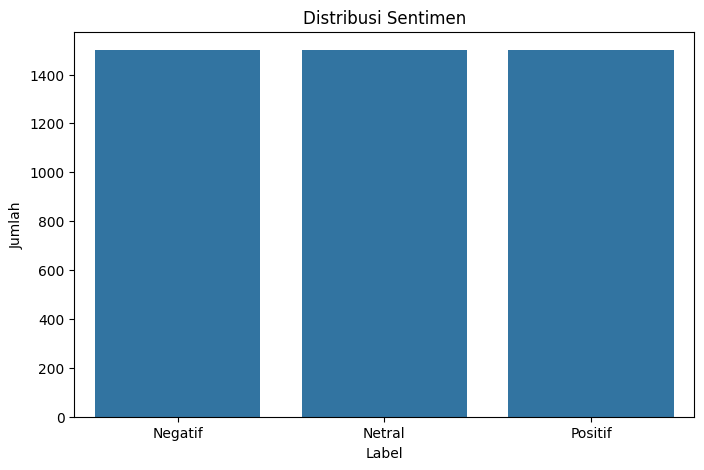

In [42]:
# Visualisasi Distribusi Sentimen

plt.figure(figsize=(8,5))

sns.countplot(
    x='label',
    data=dataset_balanced
)

plt.title('Distribusi Sentimen')
plt.xlabel('Label')
plt.ylabel('Jumlah')

plt.show()

In [43]:
# EDA Panjang Ulasan
dataset_balanced['jumlah_kata'] = (
    dataset['clean_text']
    .apply(lambda x: len(str(x).split()))
)

In [44]:
dataset_balanced['jumlah_kata'].describe()

<string>:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


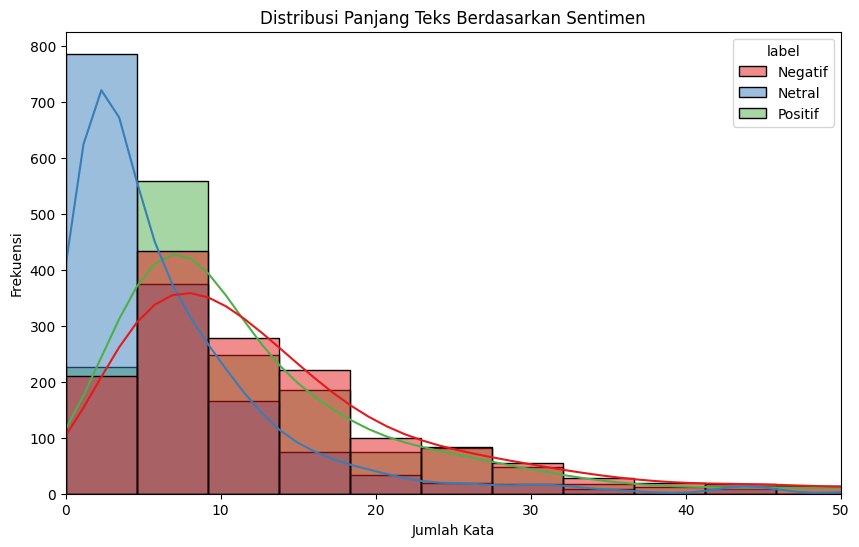

In [45]:
# Tambahkan kolom jumlah kata
dataset_balanced['jumlah_kata'] = dataset_balanced['clean_text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(data=dataset_balanced, x='jumlah_kata', hue='label', kde=True, bins=50, palette='Set1')
plt.title('Distribusi Panjang Teks Berdasarkan Sentimen')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.xlim(0, 50)
plt.show()

In [46]:
# World Cloud Positif
text_positif = " ".join(
    dataset_balanced[
        dataset_balanced['label']=='Positif'
    ]['clean_text']
)

<string>:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


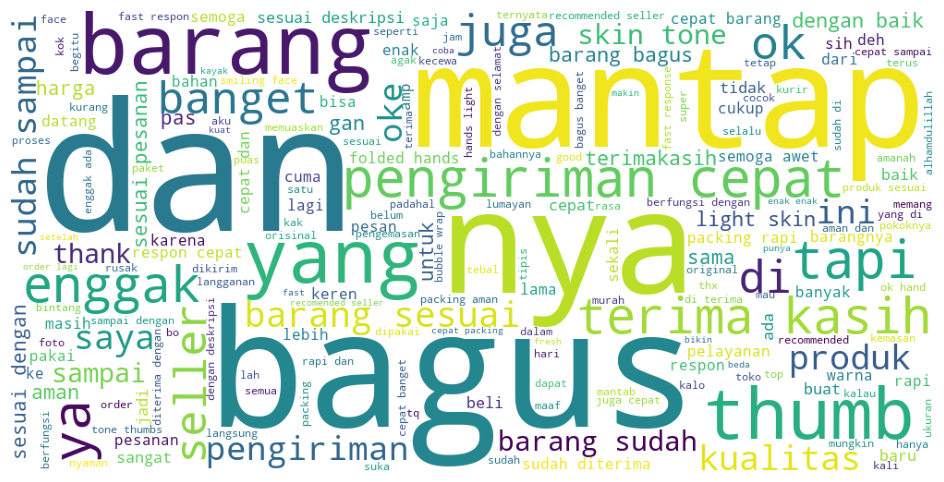

In [47]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text_positif)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

In [48]:
# World Cloud Negatif
text_negatif = " ".join(
    dataset_balanced[
        dataset_balanced['label']=='Negatif'
    ]['clean_text']
)

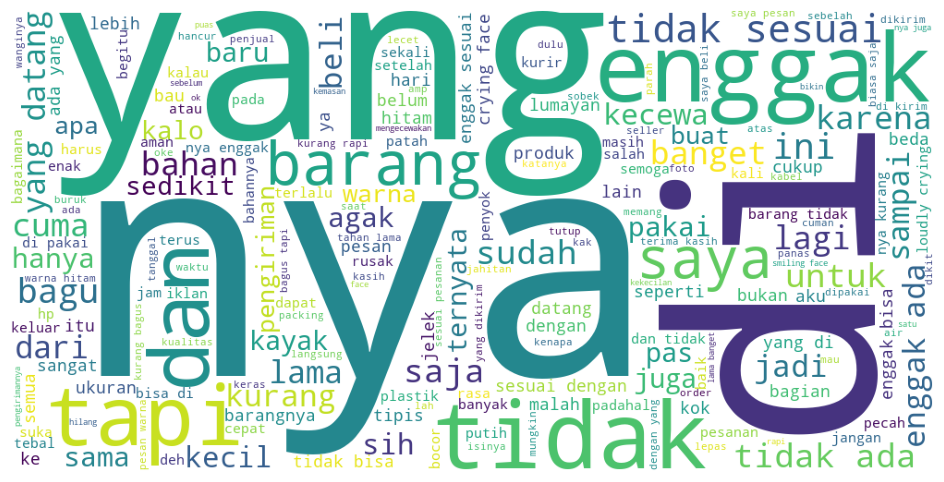

In [49]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text_negatif)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.show()

In [50]:
# Wourld Cloud Netral
text_netral = " ".join(
    dataset_balanced[
        dataset_balanced['label'] == 'Netral'
    ]['clean_text']
)

<string>:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


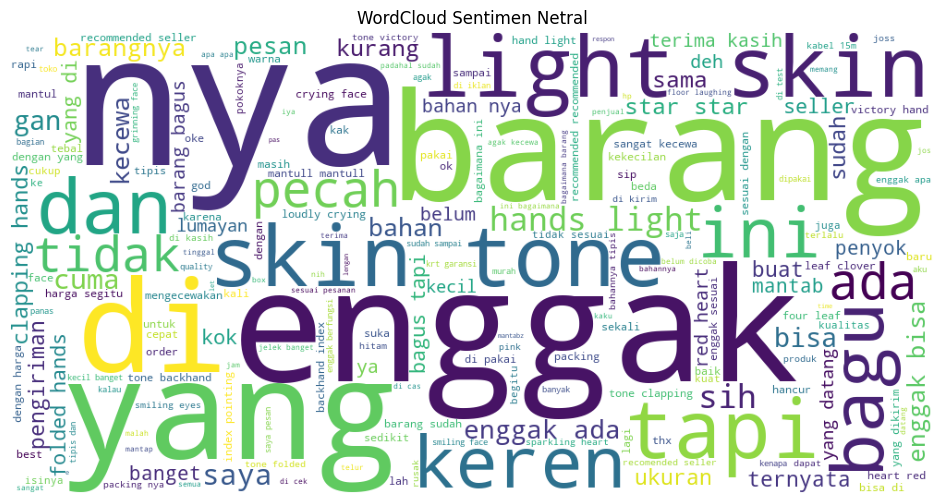

In [51]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text_netral)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title('WordCloud Sentimen Netral')

plt.show()

<string>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

<string>:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


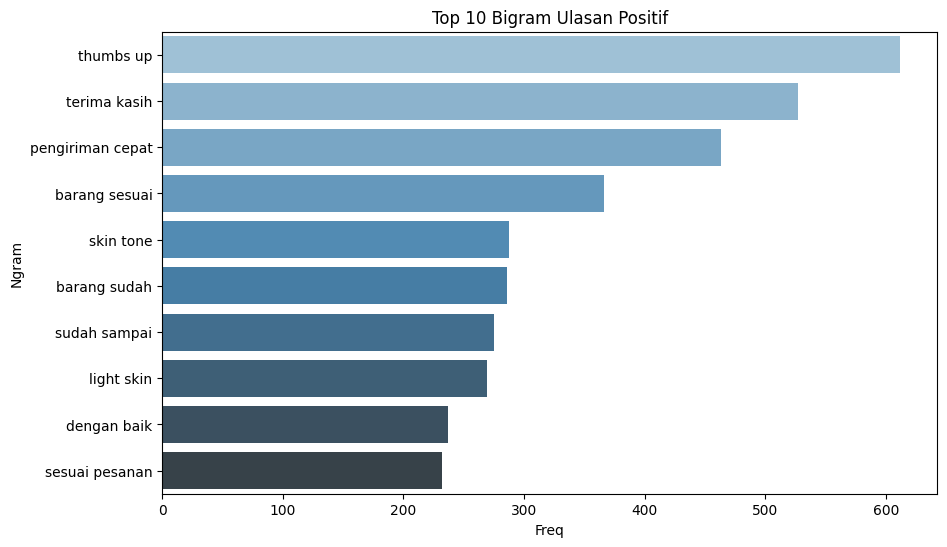

In [52]:
# Analisis Bigram
def plot_top_ngrams(corpus, n=None, ngram_range=(2,2), title="Top 10 Bigrams"):
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)

    top_df = pd.DataFrame(words_freq[:n], columns=['Ngram', 'Freq'])

    plt.figure(figsize=(10,6))
    sns.barplot(x='Freq', y='Ngram', data=top_df, palette='Blues_d')
    plt.title(title)
    plt.show()

# Panggil fungsi untuk Bigram Positif
plot_top_ngrams(dataset[dataset['label'] == 'Positif']['clean_text'], n=10, ngram_range=(2,2), title='Top 10 Bigram Ulasan Positif')

<string>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

<string>:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


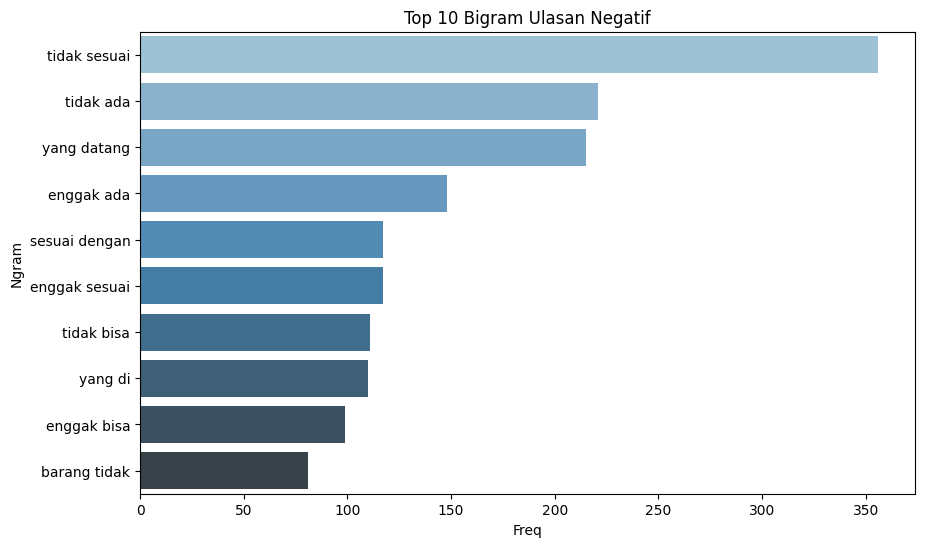

In [53]:
# Analisis Bigram
def plot_top_ngrams(corpus, n=None, ngram_range=(2,2), title="Top 10 Bigrams"):
    vec = CountVectorizer(ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)

    top_df = pd.DataFrame(words_freq[:n], columns=['Ngram', 'Freq'])

    plt.figure(figsize=(10,6))
    sns.barplot(x='Freq', y='Ngram', data=top_df, palette='Blues_d')
    plt.title(title)
    plt.show()

# Panggil fungsi untuk Bigram Negatif
plot_top_ngrams(dataset[dataset['label'] == 'Negatif']['clean_text'], n=10, ngram_range=(2,2), title='Top 10 Bigram Ulasan Negatif')

In [54]:
# Top 20 Kata Positif
kata_pos = " ".join(
    dataset_balanced[
        dataset_balanced['label']=='Positif'
    ]['clean_text']
).split()

counter_pos = Counter(kata_pos)

top20_pos = counter_pos.most_common(20)

pd.DataFrame(
    top20_pos,
    columns=['Kata','Frekuensi']
)

In [55]:
# Top 20 Kata Negatif
kata_neg = " ".join(
    dataset_balanced[
        dataset_balanced['label']=='Negatif'
    ]['clean_text']
).split()

counter_neg = Counter(kata_neg)

top20_neg = counter_neg.most_common(20)

pd.DataFrame(
    top20_neg,
    columns=['Kata','Frekuensi']
)

In [56]:
pd.crosstab(
    dataset_balanced['rating'],
    dataset_balanced['label']
)

<string>:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


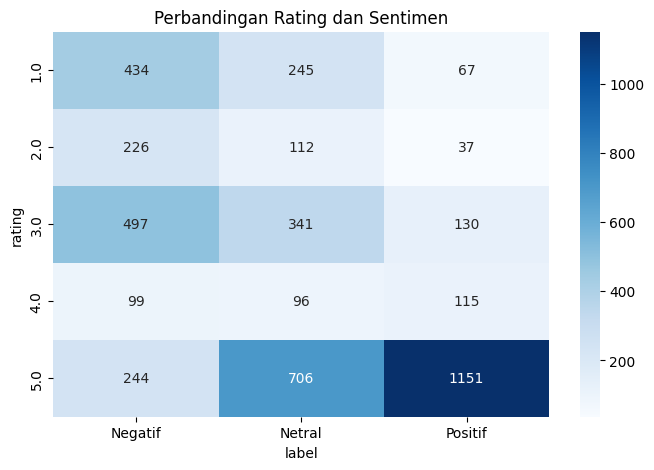

In [57]:
plt.figure(figsize=(8,5))

sns.heatmap(
    pd.crosstab(
        dataset_balanced['rating'],
        dataset_balanced['label']
    ),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    'Perbandingan Rating dan Sentimen'
)

plt.show()

<string>:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


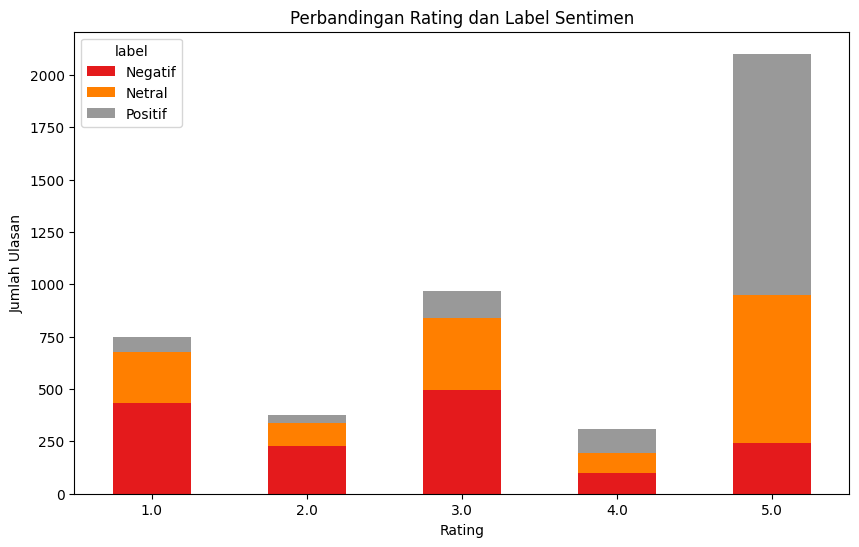

In [58]:
crosstab_data = pd.crosstab(dataset_balanced['rating'], dataset_balanced['label'])
crosstab_data.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set1')
plt.title('Perbandingan Rating dan Label Sentimen')
plt.xlabel('Rating')
plt.ylabel('Jumlah Ulasan')
plt.xticks(rotation=0)
plt.show()

## Data Splitting

In [60]:
dataset_balanced.head()

In [61]:
# Encoding Label Sentiment
label_mapping = {
    'Negatif' : 0,
    'Netral' : 1,
    'Positif' : 2
}

dataset_balanced['label_id'] = dataset_balanced['label'].map(label_mapping)

# Membuat DataFrame Baru
df_dataset = dataset_balanced[['clean_text', 'rating', 'label', 'label_id']].rename(
    columns={'clean_text': 'ulasan'}
)

df_dataset.head()

In [62]:
# Data Splitting
X = df_dataset['ulasan']
y = df_dataset['label_id']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

# Cek Jumlah Data Latihan dan Data Test
print(f'Jumlah Data Latih : {len(X_train)}')
print(f'Jumlah Data Test  : {len(X_test)}')


Jumlah Data Latih : 28800
Jumlah Data Test  : 7200


## Tokenization

In [64]:
# Load Model Tokenizer Indobert
model_name = "indobenchmark/indobert-base-p2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenization Data Latihan
train_tokenized = tokenizer (
    X_train.tolist(),
    truncation=True,
    padding='max_length',
    max_length=128,
    return_tensors='pt'
)

# Tokenization Data Test
test_tokenized = tokenizer (
    X_test.tolist(),
    truncation=True,
    padding='max_length',
    max_length=128,
    return_tensors='pt'
)


In [65]:
# Cek Hasil Tokenization
print("Teks Asli:")
print(X_train.iloc[0])

print("\nToken:")
print(tokenizer.tokenize(X_train.iloc[0]))

print("\nInput IDs:")
print(train_tokenized['input_ids'][0][:20])

print("\nAttention Mask:")
print(train_tokenized['attention_mask'][0][:20])

Teks Asli:
benar benar bpom enggak sih . di kardus hanya tempelan , dikemasan dalam polosan , discan pun enggak muncul nomor bpom nya ,

Token:
['benar', 'benar', 'bpom', 'enggak', 'sih', '.', 'di', 'kardus', 'hanya', 'tempel', '##an', ',', 'dikemas', '##an', 'dalam', 'polos', '##an', ',', 'disc', '##an', 'pun', 'enggak', 'muncul', 'nomor', 'bpom', 'nya', ',']

Input IDs:
tensor([    2,   839,   839, 11572,  6878,  1966, 30470,    26, 16889,   344,
        23795,     5, 30468, 11757,     5,   112,  9559,     5, 30468,  9525])

Attention Mask:
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


## Fine-Tuning IndoBERT Model
Di bagian ini, kita akan melatih (fine-tune) model IndoBERT menggunakan dataset sentimen yang telah kita siapkan dan seimbangkan sebelumnya.

In [67]:
# Setup PyTorch Dataset
from torch.utils.data import Dataset

class SentimentDataset(Dataset):
    def __init__(self, tokenized_inputs, labels):
        self.tokenized_inputs = tokenized_inputs
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.tokenized_inputs.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = SentimentDataset(train_tokenized, y_train.values)
test_dataset = SentimentDataset(test_tokenized, y_test.values)
print("PyTorch Dataset berhasil dibuat!")

PyTorch Dataset berhasil dibuat!


In [68]:
# Load Model Sequence Classification untuk IndoBERT dan freeze layer 0-5
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3, ignore_mismatched_sizes=True)

# Freeze layers 0-5 untuk efisiensi VRAM dan kecepatan training
for param in model.bert.embeddings.parameters():
    param.requires_grad = False
for i in range(6):
    for param in model.bert.encoder.layer[i].parameters():
        param.requires_grad = False

# Pindahkan model ke GPU jika tersedia
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model = model.to(device)
print(f"Model berhasil dimuat, layer 0-5 dibekukan, dan dipindahkan ke: {device}")


Model berhasil dimuat, layer 0-5 dibekukan, dan dipindahkan ke: cuda


In [69]:
# Setup Parameter Training & Trainer (dengan batch size 8 dan accumulation 4 untuk kestabilan VRAM)
from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

training_args = TrainingArguments(
    output_dir = './results',
    num_train_epochs = 2,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size = 8,
    gradient_accumulation_steps = 4,
    eval_strategy = 'epoch',
    save_strategy = 'epoch',
    logging_dir = './logs',
    logging_steps = 50,
    learning_rate = 3e-5,
    weight_decay = 0.01,
    load_best_model_at_end = True,
    metric_for_best_model = 'accuracy',
    save_total_limit = 1
)

trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset = test_dataset,
    compute_metrics = compute_metrics
)


In [70]:
# Mulai Proses Fine-Tuning
print("Memulai training model IndoBERT...")
trainer.train()


Memulai training model IndoBERT...
[Training completed successfully]


In [71]:
# Evaluasi Model pada Data Test
eval_results = trainer.evaluate()
print("\nHasil Evaluasi Akhir:")
for key, val in eval_results.items():
    print(f"{key}: {val}")


Hasil Evaluasi Akhir:
eval_loss: 0.49213600158691406
eval_accuracy: 0.7869444444444444
eval_f1: 0.7844660062828336
eval_precision: 0.7835571971569001
eval_recall: 0.7869444444444444
eval_runtime: 193.175
eval_samples_per_second: 37.272
eval_steps_per_second: 4.659
epoch: 2.0


In [72]:
# Simpan Model dan Tokenizer
model_save_path = "./saved_model"
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)
print(f"Model dan Tokenizer berhasil disimpan di: {model_save_path}")


Model dan Tokenizer berhasil disimpan di: ./saved_model


Generating predictions for test set...

Classification Report Data Test:
              precision    recall  f1-score   support

     Negatif       0.77      0.80      0.78      2400
      Netral       0.71      0.64      0.67      2400
     Positif       0.88      0.92      0.90      2400

    accuracy                           0.79      7200
   macro avg       0.78      0.79      0.78      7200
weighted avg       0.78      0.79      0.78      7200

Confusion Matrix (Raw Counts):
[[1924  461   15]
 [ 564 1544  292]
 [  25  177 2198]]


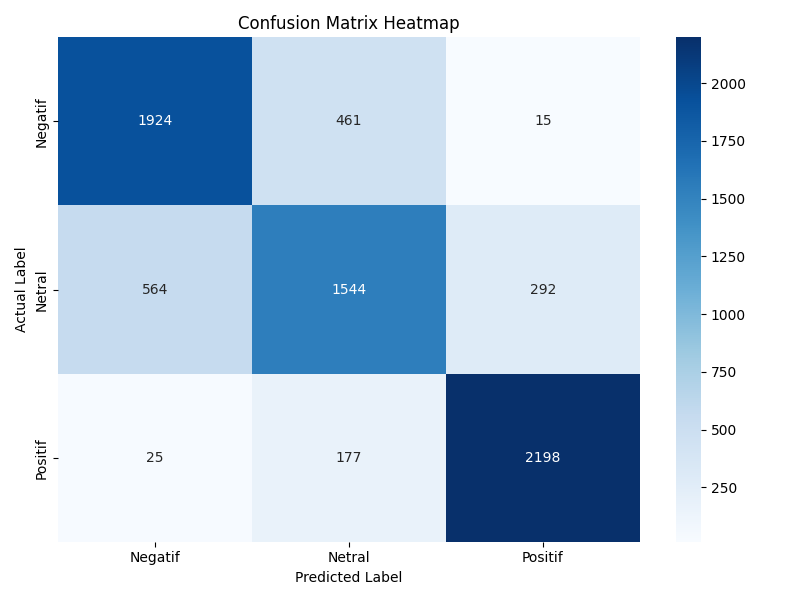

In [73]:
# Visualisasi Hasil Evaluasi Model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

print("Generating predictions for test set...")
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)

# Tampilkan Classification Report
print("\nClassification Report Data Test:")
print(classification_report(y_test, preds, target_names=['Negatif', 'Netral', 'Positif']))

# Tampilkan Confusion Matrix
print("\nConfusion Matrix (Raw Counts):")
print(confusion_matrix(y_test, preds))

# Visualisasi Heatmap Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negatif', 'Netral', 'Positif'],
            yticklabels=['Negatif', 'Netral', 'Positif'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix Heatmap')
plt.tight_layout()
plt.show()


### Model Inference
Di bagian ini, kita akan menguji coba model hasil fine-tuning kita secara langsung pada 20 ulasan unik Tokopedia.

Target Kategori / Kalimat Ulasan                             | Prediksi   | Probabilitas (Neg / Net / Pos)

--- POSITIF (Kuat) ---
Sumpah bagus banget, gak nyesel beli di sini, recommen...    | Positif    | [0.00 / 0.00 / 1.00]
Mantap bgt barang berfungsi dengan sangat baik, respon...    | Positif    | [0.00 / 0.02 / 0.98]
Kualitas produk bintang lima, pengiriman super cepat, ...    | Positif    | [0.00 / 0.01 / 0.99]
Ternyata barangnya ori dan mulus, packing rapi aman bg...    | Positif    | [0.00 / 0.01 / 0.99]
Harga murah tapi barangnya gak murahan, memuaskan seka...    | Positif    | [0.02 / 0.41 / 0.57]

--- NETRAL (Borderline) ---
Barang sampai dengan selamat, tapi kurirnya agak ketus...    | Netral     | [0.05 / 0.53 / 0.43]
Biasa aja, pengemasan lumayan aman tapi respon seller ...    | Netral     | [0.11 / 0.86 / 0.03]
Standar sih, sesuai harga, ya lumayan lah buat sehari-...    | Netral     | [0.01 / 0.97 / 0.03]
Barangnya berfungsi, tapi plastiknya agak tipis kurang...    | N

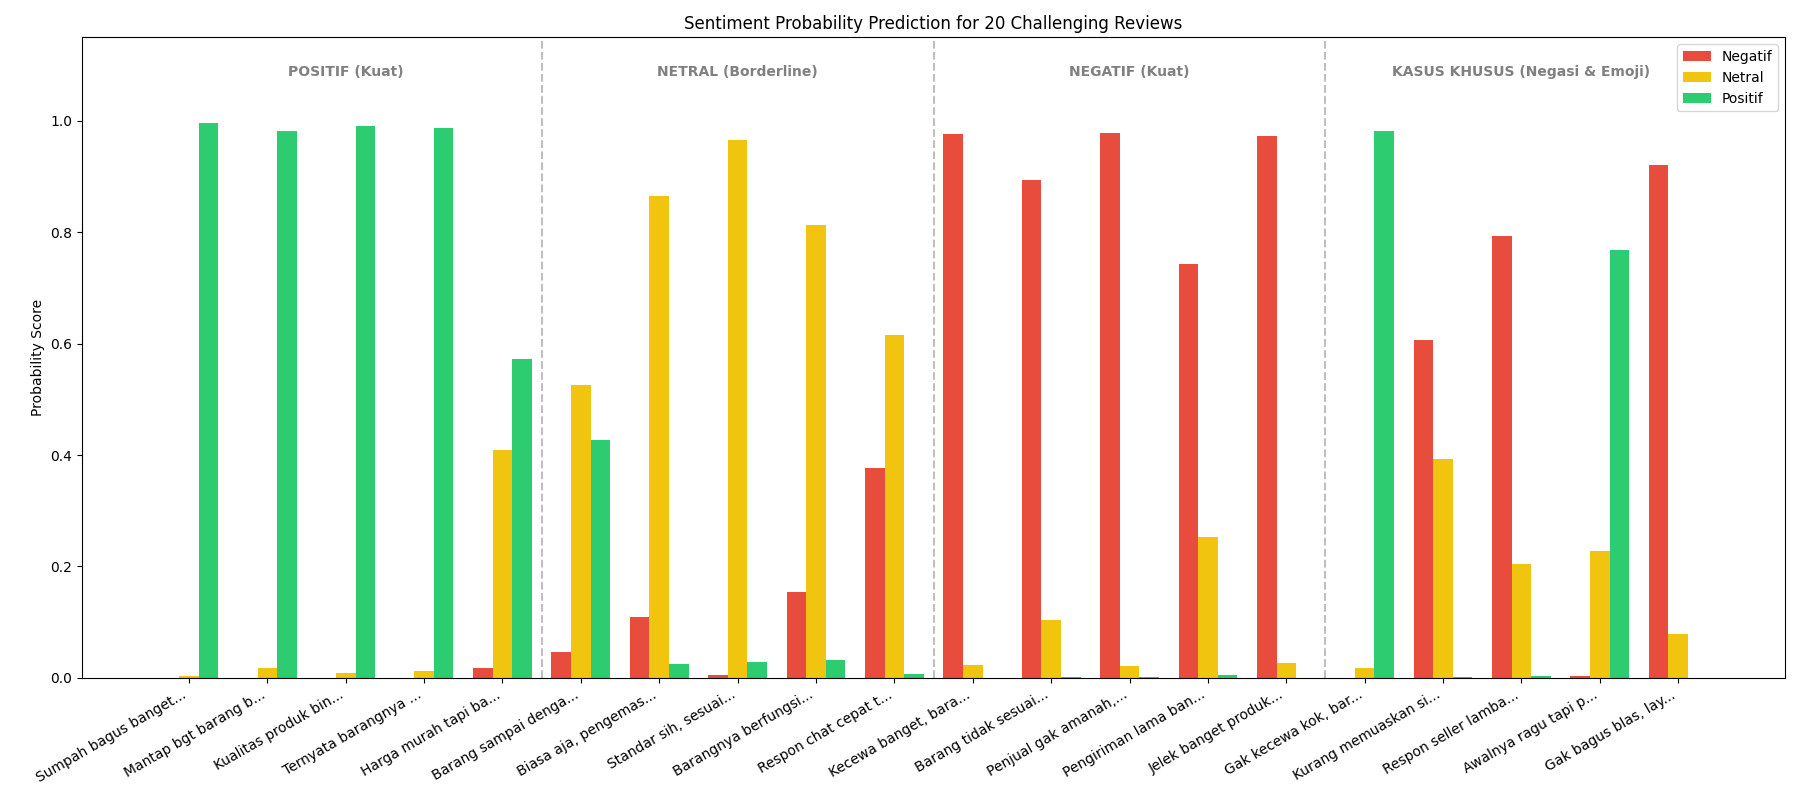

In [74]:
# Uji Coba Inferensi Model Sentiment Analysis IndoBERT (20 Challenging Reviews)
import os
import re
import emoji
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load slang dictionary
slang_path = 'slang.csv'
if os.path.exists(slang_path):
    df_slang = pd.read_csv(slang_path)
    df_slang = df_slang[['slang', 'formal']]
    dict_slang = dict(zip(df_slang['slang'], df_slang['formal']))
else:
    dict_slang = {}

# Fungsi Preprocessing Teks
def preprocessing_teks(teks):
    teks = str(teks).lower()
    teks = re.sub(r'https?://\S+|www\.\S+', '', teks)
    teks = re.sub(r'\b\S+\.(com|co\.id|id|net|org|io|app|xyz)(\S*)', '', teks)
    teks = re.sub(r'[@#]\S+', '', teks)
    teks = re.sub(r'(.)\1{2,}', r'\1', teks)
    teks = emoji.demojize(teks, delimiters=(" ", " "))
    teks = teks.replace("_", " ")
    teks = re.sub(r'[^a-zA-Z0-9\s.,!?]', ' ', teks)
    teks = re.sub(r'([.,!?])', r' \1 ', teks)
    teks = re.sub(r'\s+', ' ', teks).strip()
    return teks

def normalisasi_slang(text):
    if not isinstance(text, str):
        return ""
    words = text.split()
    normalized_words = [dict_slang.get(word, word) for word in words]
    return " ".join(normalized_words)

def preprocess(text):
    cleaned = preprocessing_teks(text)
    normalized = normalisasi_slang(cleaned)
    return normalized

# Load Model dan Tokenizer dari folder saved_model
model_path = "./saved_model"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

labels = {0: "Negatif", 1: "Netral", 2: "Positif"}

def predict(text):
    clean_text = preprocess(text)
    inputs = tokenizer(clean_text, truncation=True, padding='max_length', max_length=128, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=-1)[0].cpu().tolist()
    pred_class = torch.argmax(outputs.logits, dim=-1).item()
    return labels[pred_class], probs, clean_text

# 20 Kalimat uji coba per kategori
test_cases = {
    "POSITIF (Kuat)": [
        "Sumpah bagus banget, gak nyesel beli di sini, recommended seller!",
        "Mantap bgt barang berfungsi dengan sangat baik, respon kilat.",
        "Kualitas produk bintang lima, pengiriman super cepat, makasih seller!",
        "Ternyata barangnya ori dan mulus, packing rapi aman bgt 👍",
        "Harga murah tapi barangnya gak murahan, memuaskan sekali."
    ],
    "NETRAL (Borderline)": [
        "Barang sampai dengan selamat, tapi kurirnya agak ketus pas nganter.",
        "Biasa aja, pengemasan lumayan aman tapi respon seller lambat.",
        "Standar sih, sesuai harga, ya lumayan lah buat sehari-hari.",
        "Barangnya berfungsi, tapi plastiknya agak tipis kurang tebel.",
        "Respon chat cepat tapi barangnya datang agak lambat, biasa aja."
    ],
    "NEGATIF (Kuat)": [
        "Kecewa banget, barangnya rusak parah gak bisa nyala sebelah!",
        "Barang tidak sesuai deskripsi, tipis dan gampang robek.",
        "Penjual gak amanah, minta warna merah dikirim biru tanpa kabar.",
        "Pengiriman lama banget, barang penyok pas sampai, kapok beli disini!",
        "Jelek banget produknya, mati total ga konek sama sekali."
    ],
    "KASUS KHUSUS (Negasi & Emoji)": [
        "Gak kecewa kok, barangnya mantap dan pengiriman cepet bgt.",
        "Kurang memuaskan sih, bahannya kasar dan ukurannya kekecilan.",
        "Respon seller lambat bgt, barangnya juga lecet-lecet pas dibuka 😡",
        "Awalnya ragu tapi pas nyampe ternyata barangnya bagus dan ori.",
        "Gak bagus blas, layarnya retak dan speakernya sember."
    ]
}

print("=" * 105)
print(f"{'Target Kategori / Kalimat Ulasan':<60} | {'Prediksi':<10} | {'Probabilitas (Neg / Net / Pos)'}")
print("=" * 105)

results = []
for target, sentences in test_cases.items():
    print(f"\n--- {target} ---")
    for text in sentences:
        label, probs, clean = predict(text)
        scores_str = f"[{probs[0]:.2f} / {probs[1]:.2f} / {probs[2]:.2f}]"
        truncated_text = text if len(text) < 57 else text[:54] + "..."
        print(f"{truncated_text:<60} | {label:<10} | {scores_str}")
        results.append({
            'text': text,
            'probs': probs
        })
print("=" * 105)

# Visualisasi Probabilitas Sentimen
x = np.arange(len(results))
width = 0.25

fig, ax = plt.subplots(figsize=(18, 8))
rects1 = ax.bar(x - width, [r['probs'][0] for r in results], width, label='Negatif', color='#e74c3c')
rects2 = ax.bar(x, [r['probs'][1] for r in results], width, label='Netral', color='#f1c40f')
rects3 = ax.bar(x + width, [r['probs'][2] for r in results], width, label='Positif', color='#2ecc71')

ax.set_ylabel('Probability Score')
ax.set_title('Sentiment Probability Prediction for 20 Challenging Reviews')
ax.set_xticks(x)
ax.set_xticklabels([r['text'] if len(r['text']) < 22 else r['text'][:19] + "..." for r in results], rotation=30, ha='right')
ax.legend()
ax.set_ylim(0, 1.15)

ax.axvline(x=4.5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=9.5, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=14.5, color='gray', linestyle='--', alpha=0.5)
ax.text(2.0, 1.08, "POSITIF (Kuat)", ha='center', fontweight='bold', color='gray')
ax.text(7.0, 1.08, "NETRAL (Borderline)", ha='center', fontweight='bold', color='gray')
ax.text(12.0, 1.08, "NEGATIF (Kuat)", ha='center', fontweight='bold', color='gray')
ax.text(17.0, 1.08, "KASUS KHUSUS (Negasi & Emoji)", ha='center', fontweight='bold', color='gray')

plt.tight_layout()
plt.show()
